# 📊 Análise Exploratória de Dados (EDA) — Titanic Dataset

## 🌍 Contexto do problema

O naufrágio do RMS Titanic, ocorrido em abril de 1912, permanece como um dos desastres marítimos mais conhecidos da história. Além do impacto histórico e social, o evento tornou-se também um importante objeto de estudo em áreas relacionadas à estatística, análise de dados e aprendizado de máquina.

O dataset utilizado neste projeto reúne informações sobre parte dos passageiros presentes no navio, incluindo dados como sexo, idade, classe social e sobrevivência. A partir dessas informações, é possível identificar padrões e relações entre diferentes características dos passageiros e suas chances de sobrevivência.

Embora o desastre tenha envolvido aproximadamente 2.200 pessoas entre passageiros e tripulação, o conjunto de dados utilizado contém registros de 891 passageiros. Dessa forma, as análises realizadas representam apenas a amostra disponível no dataset, não correspondendo à totalidade das pessoas presentes no Titanic.


## 📁 Estrutura do dataset

O dataset utilizado neste projeto contém informações sobre parte dos passageiros presentes no RMS Titanic no momento do desastre.

Os dados originais foram disponibilizados em inglês e incluem colunas relacionadas ao perfil dos passageiros, como sexo, idade, classe social, tarifa paga e sobrevivência.

Entre as principais colunas presentes no conjunto de dados estão:

- `Survived`: indica se o passageiro sobreviveu ao desastre (0 = Não | 1 = Sim);
- `Pclass`: representa a classe de embarque do passageiro (1ª, 2ª ou 3ª classe);
- `Sex`: sexo do passageiro;
- `Age`: idade;
- `SibSp`: quantidade de irmãos ou cônjuges a bordo;
- `Parch`: quantidade de pais ou filhos a bordo;
- `Ticket`: número do bilhete de embarque;
- `Fare`: tarifa paga pela viagem;
- `Cabin`: número da cabine;
- `Embarked`: porto de embarque do passageiro.

Ao longo do projeto, algumas colunas e valores foram traduzidos, tratados ou removidos com o objetivo de facilitar a interpretação dos dados e tornar as análises mais claras e organizadas.

## 📚 Importação das bibliotecas

In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 📥 Carregamento dos dados

Nesta etapa, realizamos a importação do dataset utilizando a biblioteca Pandas, criando um DataFrame para manipulação e análise dos dados.

In [276]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
tit = pd.read_csv(url)

## 🔍 Exploração inicial

Nesta etapa, analisamos a estrutura do dataset para entender sua dimensão e os tipos de dados disponíveis, o que é fundamental para orientar as etapas de tratamento e análise.

In [277]:
tit.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [278]:
tit.shape

(891, 12)

In [279]:
tit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### 📌 Observações iniciais

O dataset possui 891 registros e 12 colunas, incluindo dados numéricos e categóricos.

Observa-se a presença de valores ausentes nas colunas Age, Cabin e Embarked, sendo mais significativa em Cabin e Age.

Esses pontos reforçam a necessidade de tratamento dos dados antes da realização de análises mais aprofundadas.

## 🧹 Tratamento de dados

Antes de seguir para as análises, é necessário avaliar e tratar os valores ausentes para garantir maior consistência no dataset.

### 🔍 Verificação de valores ausentes

Nesta etapa, quantificamos os valores ausentes nas colunas previamente identificadas, com o objetivo de dimensionar o volume de dados faltantes em cada campo e definir o tratamento mais adequado.

In [280]:
tit.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


### 🔧 Aplicação do tratamento

Nesta etapa, foram aplicadas técnicas de preenchimento e remoção de valores ausentes, considerando as características de cada coluna e buscando preservar a integridade das informações.

In [281]:
tit['Age'] = tit['Age'].fillna(tit['Age'].median())

tit['Cabin'] = tit['Cabin'].fillna(tit['Cabin'].mode()[0])

tit = tit.dropna(subset=['Embarked'])

### ✅ Verificação após tratamento

Após a aplicação do tratamento, foi realizada uma nova verificação para confirmar que os dados foram ajustados corretamente e que o dataset permaneceu consistente.

Essa etapa é importante para garantir segurança antes de seguir para as próximas fases de preparação dos dados.

In [282]:
tit.isnull().sum().sort_values(ascending=False)

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [283]:
tit.shape

(889, 12)

#### 📌 Observação

Após a remoção dos registros com valores ausentes na coluna Embarked, o dataset passou a conter 889 registros válidos para análise.

## 🧩 Organização das colunas

Nesta etapa, foram realizadas alterações estruturais no dataset, com o objetivo de simplificar a base de dados e melhorar a organização das informações utilizadas nas análises.

### 🔧 Remoção de colunas

Algumas colunas foram removidas por não contribuírem diretamente para o contexto das análises propostas, permitindo um dataset mais objetivo e organizado.

In [284]:
tit = tit.drop(['SibSp', 'Parch', 'Ticket'], axis=1, errors='ignore')
tit.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,B96 B98,S


### 🏷️ Renomeação de colunas

As colunas restantes foram renomeadas para o idioma português, com o objetivo de facilitar a leitura e tornar a interpretação dos dados mais intuitiva ao longo da análise.

In [285]:
tit.rename(columns={
    'PassengerId': 'IdPassageiro',
    'Survived': 'Sobreviveu',
    'Pclass': 'Classe',
    'Name': 'Nome',
    'Sex': 'Sexo',
    'Age': 'Idade',
    'Fare': 'Tarifa',
    'Cabin': 'Cabine',
    'Embarked': 'Embarque'
}, inplace=True)

tit.head()

,IdPassageiro,Sobreviveu,Classe,Nome,Sexo,Idade,Tarifa,Cabine,Embarque
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,B96 B98,S


## 🔄 Padronização dos dados

Após os ajustes estruturais, foram realizadas padronizações em colunas categóricas para tornar os dados mais claros e facilitar a interpretação dos resultados.

### 🔤 Conversão da coluna Sobreviveu

Os valores numéricos da coluna Sobreviveu foram convertidos para formato textual, tornando a visualização das informações mais intuitiva durante as análises.

In [286]:
tit['Sobreviveu'] = tit['Sobreviveu'].replace({
    0: 'Não',
    1: 'Sim'
})

tit.head()

,IdPassageiro,Sobreviveu,Classe,Nome,Sexo,Idade,Tarifa,Cabine,Embarque
0,1,Não,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,B96 B98,S
1,2,Sim,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,C85,C
2,3,Sim,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,B96 B98,S
3,4,Sim,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,C123,S
4,5,Não,3,"Allen, Mr. William Henry",male,35.0,8.0500,B96 B98,S


### 🔤 Padronização da coluna Sexo

Os valores da coluna Sexo foram traduzidos para o português, mantendo a consistência do dataset e facilitando a leitura das análises.

In [287]:
tit['Sexo'] = tit['Sexo'].replace({
    'male': 'Homem',
    'female': 'Mulher'
})

tit.head()

,IdPassageiro,Sobreviveu,Classe,Nome,Sexo,Idade,Tarifa,Cabine,Embarque
0,1,Não,3,"Braund, Mr. Owen Harris",Homem,22.0,7.2500,B96 B98,S
1,2,Sim,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mulher,38.0,71.2833,C85,C
2,3,Sim,3,"Heikkinen, Miss. Laina",Mulher,26.0,7.9250,B96 B98,S
3,4,Sim,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mulher,35.0,53.1000,C123,S
4,5,Não,3,"Allen, Mr. William Henry",Homem,35.0,8.0500,B96 B98,S


## 📊 Análises e interpretações

Após as etapas de tratamento, limpeza e organização dos dados, iniciamos as análises exploratórias com o objetivo de compreender os padrões presentes no dataset.

As análises a seguir buscam identificar relações entre fatores como sexo, faixa etária, classe social e sobrevivência, permitindo interpretar como diferentes características influenciaram as chances de sobrevivência dos passageiros durante o desastre do Titanic.

### 📊 Visão geral dos passageiros

Antes de aprofundar as análises por sexo, faixa etária e classe social, observamos inicialmente a dimensão geral do desastre, avaliando a quantidade total de passageiros presentes no dataset e o número de sobreviventes registrados.

In [288]:
total_passageiros = tit.shape[0]

sobreviventes = tit[tit['Sobreviveu'] == 'Sim'].shape[0]

nao_sobreviventes = tit[tit['Sobreviveu'] == 'Não'].shape[0]

print(f'Total de passageiros: {total_passageiros}')
print(f'Sobreviventes: {sobreviventes}')
print(f'Não sobreviventes: {nao_sobreviventes}')

Total de passageiros: 889
Sobreviventes: 340
Não sobreviventes: 549


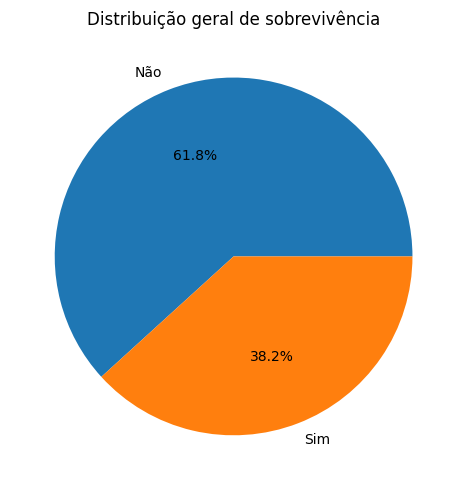

In [289]:
plt.figure(figsize=(5, 5))

tit['Sobreviveu'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ylabel=''
)

plt.title('Distribuição geral de sobrevivência')

plt.tight_layout()
plt.show()

#### 📌 Interpretação

Os dados demonstram que a maior parte dos passageiros presentes no dataset não sobreviveu ao desastre, evidenciando a dimensão do impacto causado pelo naufrágio do Titanic.

A partir dessa visão geral, torna-se possível aprofundar a análise dos fatores que influenciaram as chances de sobrevivência dos diferentes grupos presentes a bordo.

### 👥 Distribuição de passageiros por sexo

Aqui, analisamos a distribuição de passageiros por sexo, buscando compreender o perfil geral das pessoas presentes no dataset.

In [290]:
tit['Sexo'].value_counts()

,count
Sexo,
Homem,577
Mulher,312


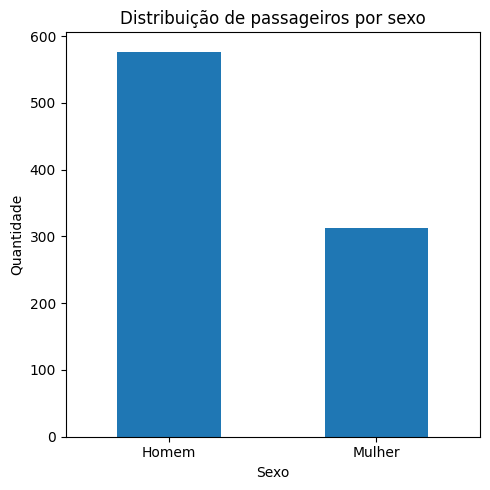

In [291]:
plt.figure(figsize=(5, 5))

tit['Sexo'].value_counts().plot(kind='bar')

plt.title('Distribuição de passageiros por sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#### 📌 Interpretação

Observa-se uma predominância de passageiros do sexo masculino no dataset, indicando uma distribuição desigual entre homens e mulheres a bordo do Titanic.

### ⚖️ Sobrevivência de adultos

Com base na distribuição geral dos passageiros, analisamos a relação entre sexo e sobrevivência entre passageiros adultos, buscando compreender como esse grupo foi afetado ao longo do processo de evacuação.

In [292]:
mulheres = tit[(tit['Sexo'] == 'Mulher') & (tit['Idade'] > 15)]
homens = tit[(tit['Sexo'] == 'Homem') & (tit['Idade'] > 15)]

resultado_adultos = pd.DataFrame({
    'Grupo': ['Mulheres', 'Homens'],
    'A bordo': [mulheres.shape[0], homens.shape[0]],
    'Sobreviventes': [
        mulheres[mulheres['Sobreviveu'] == 'Sim'].shape[0],
        homens[homens['Sobreviveu'] == 'Sim'].shape[0]
    ]
})

resultado_adultos

,Grupo,A bordo,Sobreviventes
0,Mulheres,269,203
1,Homens,537,88


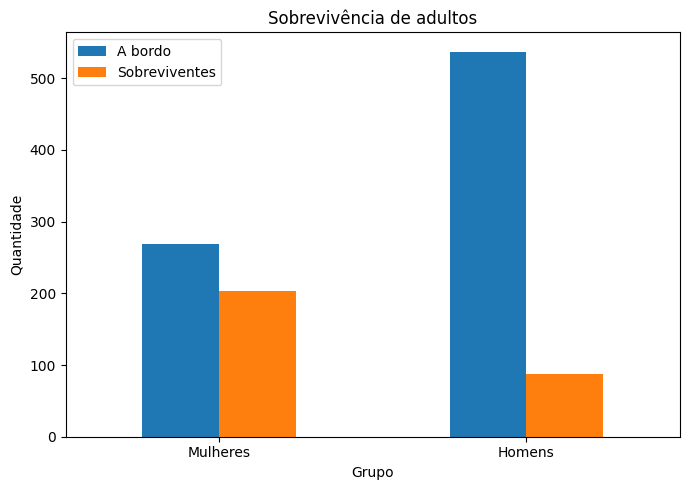

In [293]:
resultado_adultos.plot(
    x='Grupo',
    kind='bar',
    figsize=(7, 5),
    title='Sobrevivência de adultos',
    rot=0,
    ylabel='Quantidade'
)

plt.tight_layout()
plt.show()

#### 📌 Interpretação

Os resultados demonstram diferenças significativas nas taxas de sobrevivência entre homens e mulheres adultas.

Mesmo com a predominância masculina a bordo do Titanic, mulheres adultas apresentaram proporções superiores de sobrevivência, indicando que sexo exerceu influência direta durante o processo de evacuação.

### 👶 Crianças no desastre do Titanic

Além das análises relacionadas aos adultos, avaliamos também o impacto do desastre entre crianças de até 15 anos.

Para tornar a análise mais clara, os dados foram separados entre meninas e meninos, permitindo observar possíveis diferenças nas taxas de sobrevivência desse grupo durante o processo de evacuação.

In [294]:
# Meninas
meninas = tit[
    (tit['Sexo'] == 'Mulher') & (tit['Idade'] <= 15)
]

# Meninos
meninos = tit[
    (tit['Sexo'] == 'Homem') & (tit['Idade'] <= 15)
]

resultado_criancas = pd.DataFrame({
    'Grupo': ['Meninas', 'Meninos'],

    'A bordo': [
        meninas.shape[0],
        meninos.shape[0]
    ],

    'Sobreviventes': [
        meninas[meninas['Sobreviveu'] == 'Sim'].shape[0],
        meninos[meninos['Sobreviveu'] == 'Sim'].shape[0]
    ]
})

resultado_criancas

,Grupo,A bordo,Sobreviventes
0,Meninas,43,28
1,Meninos,40,21


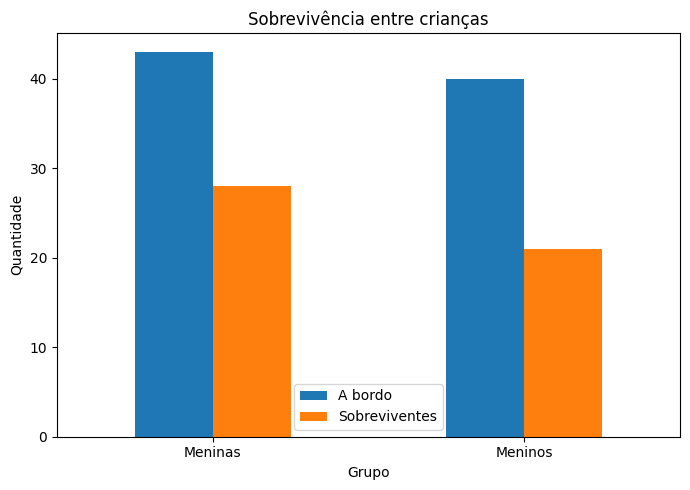

In [295]:
resultado_criancas.plot(
    x='Grupo',
    kind='bar',
    figsize=(7,5),
    title='Sobrevivência entre crianças',
    rot=0,
    ylabel='Quantidade'
)

plt.tight_layout()
plt.show()

#### 📌 Interpretação

Os resultados demonstram que meninas e meninos apresentaram taxas expressivas de sobrevivência durante o desastre.

Ao relacionar o total de crianças com a quantidade de sobreviventes, observa-se que esse grupo recebeu prioridade durante o processo de evacuação, embora ainda tenham ocorrido perdas significativas entre crianças do sexo feminino e masculino.

### 🛳️ Distribuição de passageiros por classe

Após compreender a distribuição dos passageiros por sexo e faixa etária, analisamos também como as pessoas estavam distribuídas entre as diferentes classes do Titanic.

In [296]:
tit['Classe'].value_counts()

,count
Classe,
3,491
1,214
2,184


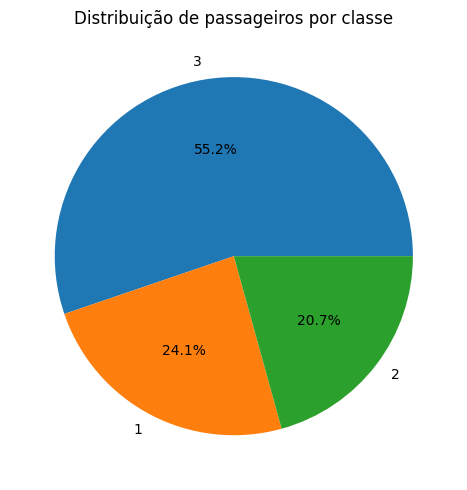

In [297]:
plt.figure(figsize=(5, 5))

tit['Classe'].value_counts().plot(
    kind='pie',
    title='Distribuição de passageiros por classe',
    autopct='%1.1f%%',
    ylabel=''
)

plt.tight_layout()
plt.show()

#### 📌 Interpretação

Os dados demonstram uma predominância de passageiros da 3ª classe, indicando que grande parte das pessoas a bordo pertencia às classes econômicas mais baixas.

### 📈 Sobrevivência por classe

Considerando a distribuição dos passageiros entre as classes, avaliamos como a posição social pode ter influenciado as chances de sobrevivência ao naufrágio.

In [298]:
tit.groupby('Classe')['Sobreviveu'].value_counts().unstack()

Sobreviveu,Não,Sim
Classe,,
1,80,134
2,97,87
3,372,119


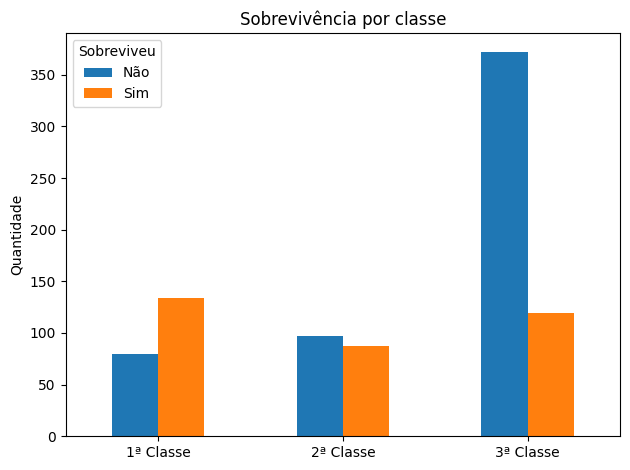

In [299]:
grafico_classe = tit.copy()

grafico_classe['Classe'] = grafico_classe['Classe'].replace({
    1: '1ª Classe',
    2: '2ª Classe',
    3: '3ª Classe'
})

grafico_classe.groupby('Classe')['Sobreviveu'].value_counts().unstack().plot(
    kind='bar',
    title='Sobrevivência por classe',
    rot=0,
    ylabel='Quantidade'
)

plt.xlabel('')
plt.tight_layout()
plt.show()

#### 📌 Interpretação

Os resultados indicam diferenças significativas nas taxas de sobrevivência entre as classes.

Passageiros da 1ª classe apresentaram maiores taxas de sobrevivência em comparação às demais classes, sugerindo que fatores sociais e estruturais influenciaram diretamente as chances de resgate.

### 🔀 Relação entre sexo, classe e sobrevivência

Após analisar separadamente fatores como sexo, faixa etária e classe social, avaliamos essas características em conjunto para compreender como elas influenciaram as chances de sobrevivência durante o desastre.

In [300]:
grupos = {
    'Mulheres': mulheres,
    'Homens': homens,
    'Meninas': meninas,
    'Meninos': meninos
}

for classe in sorted(tit['Classe'].unique()):

    resumo = pd.DataFrame({
        'Grupo': grupos.keys(),
        'A bordo': [df[df['Classe'] == classe].shape[0] for df in grupos.values()],
        'Sobreviventes': [df.query('Classe == @classe and Sobreviveu == "Sim"').shape[0] for df in grupos.values()],
        'Não sobreviventes': [df.query('Classe == @classe and Sobreviveu == "Não"').shape[0] for df in grupos.values()]
    })

    print(f'Classe {classe}')

    display(
        resumo.style
        .hide(axis='index')
    )

Classe 1


Grupo,A bordo,Sobreviventes,Não sobreviventes
Mulheres,89,87,2
Homens,119,42,77
Meninas,3,2,1
Meninos,3,3,0


Classe 2


Grupo,A bordo,Sobreviventes,Não sobreviventes
Mulheres,66,60,6
Homens,99,8,91
Meninas,10,10,0
Meninos,9,9,0


Classe 3


Grupo,A bordo,Sobreviventes,Não sobreviventes
Mulheres,114,56,58
Homens,319,38,281
Meninas,30,16,14
Meninos,28,9,19


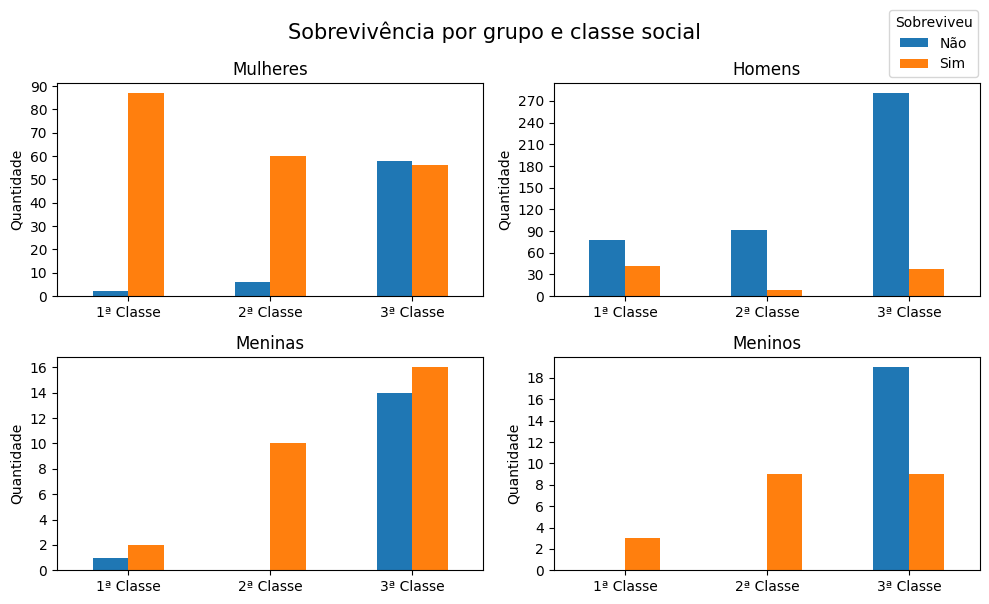

In [301]:
nomes_classes = {
    1: '1ª Classe',
    2: '2ª Classe',
    3: '3ª Classe'
}

grupos = {
    'Mulheres': mulheres,
    'Homens': homens,
    'Meninas': meninas,
    'Meninos': meninos
}

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for ax, (nome_grupo, df_grupo) in zip(axes.flatten(), grupos.items()):

    resumo = (
        df_grupo
        .groupby('Classe')['Sobreviveu']
        .value_counts()
        .unstack()
        .rename(index=nomes_classes)
    )

    resumo.plot(
        kind='bar',
        ax=ax,
        rot=0,
        title=nome_grupo,
        legend=False
    )

    ax.set_xlabel('')
    ax.set_ylabel('Quantidade')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

fig.suptitle(
    'Sobrevivência por grupo e classe social',
    fontsize=15
)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Sobreviveu',
    loc='upper right',
    bbox_to_anchor=(0.99, 1.01)
)

plt.tight_layout()
plt.show()

#### 📌 Interpretação

Os resultados reforçam padrões históricos frequentemente associados ao desastre do Titanic, especialmente a conhecida expressão “mulheres e crianças primeiro”, relacionada à priorização desses grupos durante o processo de evacuação.

Ao analisar os passageiros por grupo e classe social, observa-se que mulheres e crianças apresentaram maior número de sobreviventes em comparação aos homens adultos. Em contrapartida, a 3ª classe concentrou os maiores números de não sobreviventes, principalmente entre os homens.

Os padrões identificados demonstram como fatores sociais e estruturais influenciaram diretamente as chances de sobrevivência durante o resgate.


## ✅ Conclusão

A análise do Titanic permitiu identificar padrões importantes relacionados às chances de sobrevivência dos passageiros, considerando fatores como sexo, faixa etária e classe social.

Os resultados reforçam aspectos históricos frequentemente associados ao desastre, como a priorização de mulheres e crianças durante o processo de evacuação. Ao mesmo tempo, também evidenciam como fatores sociais e econômicos influenciaram diretamente as chances de sobrevivência, principalmente entre os passageiros da 3ª classe.

Mais do que observar números isolados, a análise mostrou como a combinação entre diferentes variáveis pode revelar padrões e relações relevantes, permitindo uma compreensão mais ampla do contexto analisado.

Além de aplicar conceitos fundamentais de tratamento, organização, visualização e interpretação de informações, este projeto também contribuiu para desenvolver um olhar mais analítico sobre como diferentes fatores podem influenciar comportamentos e acontecimentos em situações complexas.
